In [1]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf
# # # 세션 다시 시작

In [2]:
# joypy 라이브러리 설치 (필요시)
# !pip install joypy

In [3]:
import pandas as pd
from geopy.distance import geodesic # geodesic은 사용하지 않지만, 원래 코드에 있어 유지합니다.
from sklearn.neighbors import BallTree
import numpy as np

# 1. 역사 데이터 로드 (지상역 위주로 선별 필요)
# UnicodeDecodeError 해결을 위해 encoding='euc-kr' 추가
station_df = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/서울시 역사마스터 정보.csv', encoding='euc-kr')

# 2. S-DoT 위치 데이터 로드
sdot_loc_df = pd.read_excel('/content/drive/MyDrive/SSAFY/BDC/서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx')

# BallTree를 사용하기 위해 위도/경도를 라디안으로 변환
sdot_coords_rad = np.deg2rad(sdot_loc_df[['위도', '경도']].values)
station_coords_rad = np.deg2rad(station_df[['위도', '경도']].values)

# S-DoT 센서 위치로 BallTree 구축 (Haversine 거리 측정 사용)
# Haversine 거리는 (위도, 경도)를 라디안 단위로 예상합니다.
tree = BallTree(sdot_coords_rad, metric='haversine')

# 검색 반경 (미터)
radius_m = 500
# 지구 평균 반경 (미터)
earth_radius_m = 6371000
# BallTree 쿼리를 위한 반경을 라디안으로 변환
radius_rad = radius_m / earth_radius_m

# 철도 주변 센서 SN 리스트 확보
rail_sensor_sns = []

# 모든 역사에 대해 주변 센서 찾기 및 rail_sensor_sns 채우기
for i, station_row in station_df.iterrows():
    station_lat_rad = station_coords_rad[i, 0]
    station_lon_rad = station_coords_rad[i, 1]

    # BallTree를 사용하여 반경 내 센서 쿼리
    # query_radius는 인접한 센서의 인덱스 배열 목록을 반환합니다.
    indices_list = tree.query_radius([[station_lat_rad, station_lon_rad]], r=radius_rad)

    # 인접한 센서의 인덱스 추출
    nearby_sensor_indices = indices_list[0]

    # 인접 센서의 시리얼 번호 가져오기 (공백 제거 추가)
    nearby_sns_for_station = sdot_loc_df.iloc[nearby_sensor_indices]['모델 시리얼(*)'].astype(str).str.strip().tolist()

    rail_sensor_sns.extend(nearby_sns_for_station)

# 중복 제거
rail_sensor_sns = list(set(rail_sensor_sns))

# 기존의 get_nearby_sensors 함수는 더 이상 필요하지 않습니다.
# def get_nearby_sensors(station_lat, station_lon, sdot_df, radius_m=500):
#     nearby_sns = []
#     for idx, row in sdot_df.iterrows():
#         dist = geodesic((station_lat, station_lon), (row['위도'], row['경도'])).meters
#         if dist <= radius_m:
#             nearby_sns.append(row['모델 시리얼(*)'])
#     return nearby_sns


In [4]:
import pandas as pd

# CSV 파일의 첫 몇 줄만 읽어서 컬럼 이름을 확인합니다.
# 파일 전체를 로드하는 것은 시간이 오래 걸릴 수 있으므로, nrows=50000과 같은 옵션을 사용하여 일부만 로드합니다.
# 실제 파일을 보고 어떤 컬럼이 '시리얼'에 해당하는지 확인해주세요。

try:
    temp_df = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/S-DoT_NATURE_2026.03.30-04.05.csv', nrows=5, encoding='euc-kr')
    # print("CSV 파일의 컬럼 목록:")
    # for col in temp_df.columns:
    #     print(f"- {col}")
    print("\n--- 첫 5개 행 데이터 미리보기 ---")
    display(temp_df)
except Exception as e:
    print(f"CSV 파일을 읽는 중 오류 발생: {e}")
    print("파일 경로 및 인코딩을 확인해주세요.")

print("위 출력에서 실제 센서의 시리얼 번호가 포함된 컬럼 이름을 확인해주세요.")
print("확인한 후, `czkeEbb3WJPF` 셀로 이동하여 `target_columns_korean` 리스트의 '시리얼' 대신 해당 컬럼 이름으로 수정해야 합니다.")


--- 첫 5개 행 데이터 미리보기 ---


모델번호  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        16.1   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  15.2   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     14.9   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         14.7   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2     9.3   

                                                                                         시리얼  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        15.9   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  14.8   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     14.6   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         14.6   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2     9.2   

                                                                                        측정시간  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        15.5   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  14.6   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     14.4   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         14.4   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2     9.0   

                                                                                          지역  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        28.0   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  31.0   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     39.0   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         35.0   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2    47.0   

                                                                                         자치구  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        27.0   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  30.0   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     39.0   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         34.0   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2    44.0   

                                                                                         행정동  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        26.0   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  26.0   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     38.0   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         32.0   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2    41.0   

                                                                                        온도 최대(℃)  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong             NaN   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong       NaN   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong          NaN   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong              NaN   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2         NaN   

                         

위 출력에서 실제 센서의 시리얼 번호가 포함된 컬럼 이름을 확인해주세요.
확인한 후, `czkeEbb3WJPF` 셀로 이동하여 `target_columns_korean` 리스트의 '시리얼' 대신 해당 컬럼 이름으로 수정해야 합니다.


In [5]:
import pandas as pd

# 분석에 필요한 컬럼만 정의 (2번 명세서 참고)
# 실제 CSV 파일의 컬럼 이름에 맞게 수정
# 'level_1'이 센서 시리얼 번호를, 'level_2'가 측정시간을 포함하고 있습니다.
target_columns_korean = ['level_1', 'level_2', '소음 평균(dB)', '소음 최대(dB)', '진동(x) 평균(mm/s)', '진동(y) 평균(mm/s)', '진동(z) 평균(mm/s)']

# 디버깅: rail_sensor_sns 샘플 출력 (PqxaWkUERJFR에서 공백 제거 후)
print(f"\nSample of rail_sensor_sns (first 5, after stripping in previous cell): {rail_sensor_sns[:5]}")
print(f"Number of unique serials in rail_sensor_sns: {len(rail_sensor_sns)}")

filtered_data = []

# CSV 파일 읽기 (모든 컬럼을 읽어 인덱스 처리 후 필터링)
chunks_iterator = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/S-DoT_NATURE_2026.03.30-04.05.csv', chunksize=50000, encoding='euc-kr')

for i, chunk in enumerate(chunks_iterator):
    # 멀티인덱스를 컬럼으로 변환합니다. 이때 시리얼 번호는 'level_1' 컬럼으로 생성됩니다.
    chunk = chunk.reset_index()

    # 디버깅: 첫 번째 청크의 컬럼 구조 확인 (reset_index 후)
    if i == 0:
        print(f"\n--- First chunk raw structure (after reset_index) ---")
        print(f"Chunk columns: {chunk.columns.tolist()}")
        print(f"Chunk head (all columns):\n{chunk.head().to_string()}")
        print("\n--- IMPORTANT: From the output above, confirm 'level_1' contains actual sensor serial numbers (e.g., 'OC3CL200014').")
        print("  - After confirmation, you MUST update `target_columns_korean` list in this cell, replacing the first item with 'level_1' if that's where serials are.")

    # 현재 target_columns_korean에서 시리얼 번호 컬럼으로 지정된 이름을 사용합니다.
    try:
        current_chunk_serial_col_name = target_columns_korean[0] # 'level_1'로 지정

        if current_chunk_serial_col_name not in chunk.columns:
            print(f"Error: Serial number column '{current_chunk_serial_col_name}' not found in chunk columns {chunk.columns.tolist()}. Please update `target_columns_korean` to the correct serial column (likely 'level_1').")
            continue

        # 시리얼 컬럼의 데이터 타입을 문자열로 변환 후 공백 제거
        chunk[current_chunk_serial_col_name] = chunk[current_chunk_serial_col_name].astype(str).str.strip()

        # 추가 디버깅: 첫 번째 청크에서 rail_sensor_sns와의 교집합 확인
        if i == 0:
            chunk_sns = set(chunk[current_chunk_serial_col_name].unique())
            overlap_in_chunk = chunk_sns.intersection(rail_sensor_sns)
            print(f"\nDEBUG: Unique SNs in first chunk ('{current_chunk_serial_col_name}'): {len(chunk_sns)}")
            print(f"DEBUG: Overlapping SNs in first chunk with rail_sensor_sns: {len(overlap_in_chunk)}")
            if overlap_in_chunk:
                print(f"DEBUG: Sample of overlapping SNs in first chunk: {list(overlap_in_chunk)[:5]}")

        # 철도 주변 센서 데이터만 필터링
        temp = chunk[chunk[current_chunk_serial_col_name].isin(rail_sensor_sns)]

        # 필요한 컬럼만 선택
        # target_columns_korean에 'level_1'과 'level_2'가 포함되어 있어야 합니다.
        selected_columns = [col for col in target_columns_korean if col in chunk.columns]
        temp = temp[selected_columns]

        filtered_data.append(temp)
    except Exception as e:
        print(f"Error processing chunk {i}: {e}")
        continue

# 하나로 합치기
sdot_final = pd.concat(filtered_data)

# 디버깅: sdot_final의 최종 크기 확인
print(f"\nFinal sdot_final DataFrame shape: {sdot_final.shape}")
if sdot_final.empty:
    print("sdot_final is empty. No matching data was found.")
else:
    print(f"Sample of sdot_final DataFrame:\n{sdot_final.head()}")

# 컬럼 이름을 영문으로 변경하여 일관성 유지
sdot_final = sdot_final.rename(columns={
    'level_1': 'SERIAL_NO', # 'level_1'을 'SERIAL_NO'로 변경
    'level_2': 'MSRMT_HR', # 'level_2'를 'MSRMT_HR'로 변경
    '소음 평균(dB)': 'AVG_NIS',
    '소음 최대(dB)': 'MAX_NIS',
    '진동(x) 평균(mm/s)': 'AVG_VIBR_XCRD',
    '진동(y) 평균(mm/s)': 'AVG_VIBR_YCRD',
    '진동(z) 평균(mm/s)': 'AVG_VIBR_ZCRD'
})

# 측정 관련 컬럼에 모두 NaN 값이 있는 행 제거
measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']
sdot_final = sdot_final.dropna(subset=measurement_cols, how='all')
print(f"DataFrame shape after dropping rows with all NaN measurements: {sdot_final.shape}")

# 시간 데이터 형변환 및 시간대별 평균 집계 (데이터 크기 추가 축소)
sdot_final['MSRMT_HR'] = pd.to_datetime(sdot_final['MSRMT_HR'], format='%Y-%m-%d_%H:%M:%S')
# MSRMT_HR 컬럼이 이미 존재하므로, 그룹화에 사용할 시간 컬럼에 다른 이름을 부여
sdot_final['hour_of_day'] = sdot_final['MSRMT_HR'].dt.hour
sdot_hourly = sdot_final.groupby(['SERIAL_NO', 'hour_of_day']).mean().reset_index()

# 디버깅: sdot_hourly의 최종 크기 확인
print(f"\nFinal sdot_hourly DataFrame shape: {sdot_hourly.shape}")
if sdot_hourly.empty:
    print("sdot_hourly is empty after aggregation.")
else:
    print(f"Sample of sdot_hourly DataFrame:\n{sdot_hourly.head()}")


Sample of rail_sensor_sns (first 5, after stripping in previous cell): ['V02Q1940631', 'V02Q1940633', 'V02Q1940821', 'V02Q1940667', 'OC3CL200120']
Number of unique serials in rail_sensor_sns: 696

--- First chunk raw structure (after reset_index) ---
Chunk columns: ['level_0', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5', '모델번호', '시리얼', '측정시간', '지역', '자치구', '행정동', '온도 최대(℃)', '온도 평균(℃)', '온도 최소(℃)', '습도 최대(%)', '습도 평균(%)', '습도 최소(%)', '풍속 최대(m/s)', '풍속 평균(m/s)', '풍속 최소(m/s)', '풍향 최대(m/s)', '풍향 평균(m/s)', '풍향 최소(m/s)', '조도 최대(lux)', '조도 평균(lux)', '조도 최소(lux)', '자외선 최대(UV)', '자외선 평균(UV)', '자외선 최대(UV).1', '소음 최대(dB)', '소음 평균(dB)', '소음 최소(dB)', '진동(x) 최대(mm/s)', '진동(x) 평균(mm/s)', '진동(x) 최소(mm/s)', '진동(y) 최대(mm/s)', '진동(y) 평균(mm/s)', '진동(y) 최소(mm/s)', '진동(z) 최대(mm/s)', '진동(z) 평균(mm/s)', '진동(z) 최소(mm/s)', '흑구온도 최대(℃)', '흑구온도 평균(℃)', '흑구온도 최소(℃)', '이산화질소 최대(ppm)', '이산화질소 평균(ppm)', '이산화질소 최소(ppm)', '일산화탄소 최대(ppm)', '일산화탄소 평균(ppm)', '일산화탄소 최소(ppm)', '이산화황 최대(ppm)', '이산화황 평균(ppm)', '이산화

### `rail_sensor_sns`와 `S-DoT_NATURE` 파일의 시리얼 번호 교집합 확인
이전 셀에서 `sdot_final`이 비어있는 원인을 파악하기 위해, `rail_sensor_sns` 리스트와 `S-DoT_NATURE` 데이터 파일의 실제 시리얼 번호(`level_1`) 간에 공통된 값이 있는지 확인합니다. 일치하는 값이 없다면, 필터링 결과가 비어있는 것이 정상입니다.

In [6]:
import pandas as pd

# S-DoT_NATURE 파일에서 'level_1' 컬럼의 고유한 시리얼 번호를 추출
# 효율성을 위해 첫 번째 청크에서만 시리얼 번호를 샘플링하여 비교합니다.
# 전체 파일을 읽으면 오래 걸릴 수 있으므로, 대표성을 띠는 일부 데이터만 확인합니다.

chunks_iterator = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/S-DoT_NATURE_2026.03.30-04.05.csv', chunksize=50000, encoding='euc-kr')

nature_file_sns = set()
for i, chunk in enumerate(chunks_iterator):
    chunk = chunk.reset_index() # level_1 컬럼을 만들기 위해 인덱스 리셋
    if 'level_1' in chunk.columns:
        nature_file_sns.update(chunk['level_1'].astype(str).str.strip().tolist())
    # 첫 번째 청크만 확인 후 break (데이터 규모에 따라 조정 가능)
    if i == 0:
        break

# rail_sensor_sns와 nature_file_sns 간의 교집합 확인
common_sns = set(rail_sensor_sns).intersection(nature_file_sns)

print(f"\nTotal unique SNs in rail_sensor_sns: {len(rail_sensor_sns)}")
print(f"Total unique SNs sampled from S-DoT_NATURE file ('level_1' column): {len(nature_file_sns)}")
print(f"Number of common SNs between rail_sensor_sns and S-DoT_NATURE file: {len(common_sns)}")

if common_sns:
    print(f"Sample of common SNs: {list(common_sns)[:10]}")
else:
    print("No common serial numbers found between rail_sensor_sns and S-DoT_NATURE file.")
    print("This is likely the reason why sdot_final is empty.")
    print("Please verify if the '모델 시리얼(*)' column in '서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx' file and the 'level_1' column in 'S-DoT_NATURE_2026.03.30-04.05.csv' file actually refer to the same set of sensors.")


Total unique SNs in rail_sensor_sns: 696
Total unique SNs sampled from S-DoT_NATURE file ('level_1' column): 905
Number of common SNs between rail_sensor_sns and S-DoT_NATURE file: 533
Sample of common SNs: ['V02Q1940631', 'V02Q1940633', 'V02Q1940667', 'OC3CL200120', 'V02Q1940343', 'OC3CL200015', 'OC3CL200054', 'V02Q1940560', 'V02Q1940460', 'V02Q1940273']


In [7]:
sdot_hourly.to_csv('/content/drive/MyDrive/SSAFY/BDC/sdot_hourly_preprocessed.csv', index=False)

### 저장된 `sdot_hourly_preprocessed.csv` 파일 불러오기 및 확인

In [8]:
sdot_hourly_loaded = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/sdot_hourly_preprocessed.csv')

print("\n--- Loaded sdot_hourly_preprocessed.csv Head ---")
display(sdot_hourly_loaded.head())

print("\n--- Loaded sdot_hourly_preprocessed.csv Info ---")
sdot_hourly_loaded.info()

print("\n--- Loaded sdot_hourly_preprocessed.csv Descriptive Statistics ---")
display(sdot_hourly_loaded.describe())


--- Loaded sdot_hourly_preprocessed.csv Head ---


,SERIAL_NO,hour_of_day,MSRMT_HR,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
0,OC3CL200158,0,2026-04-02 00:07:00,NaN,NaN,NaN,NaN,0.741857
1,OC3CL200158,1,2026-04-02 01:07:00,NaN,NaN,NaN,NaN,0.745143
2,OC3CL200158,2,2026-04-02 02:07:00,NaN,NaN,NaN,NaN,0.741857
3,OC3CL200158,3,2026-04-02 15:07:00,NaN,NaN,NaN,NaN,0.732833
4,OC3CL200158,4,2026-04-02 16:07:00,NaN,NaN,NaN,NaN,0.714667



--- Loaded sdot_hourly_preprocessed.csv Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9811 entries, 0 to 9810
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SERIAL_NO      9811 non-null   object 
 1   hour_of_day    9811 non-null   int64  
 2   MSRMT_HR       9811 non-null   object 
 3   AVG_NIS        9721 non-null   float64
 4   MAX_NIS        9721 non-null   float64
 5   AVG_VIBR_XCRD  9721 non-null   float64
 6   AVG_VIBR_YCRD  0 non-null      float64
 7   AVG_VIBR_ZCRD  786 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 613.3+ KB

--- Loaded sdot_hourly_preprocessed.csv Descriptive Statistics ---


,hour_of_day,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
count,9811.000000,9721.000000,9721.000000,9721.000000,0.0,786.000000
mean,11.499439,0.061872,0.066266,1.016543,NaN,0.523677
std,6.923249,0.039325,0.039409,0.117341,NaN,0.369289
min,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,5.000000,0.028571,0.030000,1.008571,NaN,0.263536
50%,12.000000,0.055714,0.060000,1.030000,NaN,0.494929
75%,17.500000,0.090000,0.091429,1.050000,NaN,0.672821
max,23.000000,0.221429,0.382857,1.135714,NaN,2.000000


### 역사 영향권 내 센서 데이터 집계

각 역사별 영향권 내에 존재하는 S-DoT 센서들의 소음 및 진동 데이터를 평균하여, 역사별 환경 정보를 집계합니다. 이 데이터는 지도에 역사 영향권을 표시할 때 사용될 상세 툴팁 정보로 활용됩니다.

In [9]:
import pandas as pd
import numpy as np

# Assuming tree, radius_m, station_df, sdot_loc_df, sdot_hourly_loaded are available from previous cells

station_aggregated_metrics = []
measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']

for i, station_row in station_df.iterrows(): # Use the existing station_df
    station_lat_rad = station_coords_rad[i, 0] # Use existing station_coords_rad
    station_lon_rad = station_coords_rad[i, 1]

    # Use the existing tree and radius_rad
    indices_list = tree.query_radius([[station_lat_rad, station_lon_rad]], r=radius_rad)
    nearby_sensor_indices = indices_list[0]

    nearby_sns_for_station = sdot_loc_df.iloc[nearby_sensor_indices]['모델 시리얼(*)'].astype(str).str.strip().tolist() # Use existing sdot_loc_df

    if nearby_sns_for_station:
        station_nearby_sensor_data = sdot_hourly_loaded[sdot_hourly_loaded['SERIAL_NO'].isin(nearby_sns_for_station)]

        if not station_nearby_sensor_data.empty:
            avg_metrics = station_nearby_sensor_data[measurement_cols].mean().to_dict()
            station_aggregated_metrics.append({
                '역사_ID': station_row['역사_ID'],
                '역사명': station_row['역사명'],
                '호선': station_row['호선'],
                '위도': station_row['위도'],
                '경도': station_row['경도'],
                'NUM_NEARBY_SENSORS': len(nearby_sns_for_station),
                **avg_metrics
            })
        else:
            station_aggregated_metrics.append({
                '역사_ID': station_row['역사_ID'],
                '역사명': station_row['역사명'],
                '호선': station_row['호선'],
                '위도': station_row['위도'],
                '경도': station_row['경도'],
                'NUM_NEARBY_SENSORS': len(nearby_sns_for_station),
                **{col: np.nan for col in measurement_cols}
            })
    else:
        station_aggregated_metrics.append({
            '역사_ID': station_row['역사_ID'],
            '역사명': station_row['역사명'],
            '호선': station_row['호선'],
            '위도': station_row['위도'],
            '경도': station_row['경도'],
            'NUM_NEARBY_SENSORS': 0,
            **{col: np.nan for col in measurement_cols}
        })

station_plot_df = pd.DataFrame(station_aggregated_metrics)
print("\n--- Station Aggregated Metrics Head ---")
display(station_plot_df.head())
print(f"Shape of station_plot_df: {station_plot_df.shape}")

# Filter out stations with no nearby sensors/data for plotting relevant info
station_plot_df_filtered = station_plot_df.dropna(subset=measurement_cols, how='all')
print(f"Shape of station_plot_df after filtering for valid sensor data: {station_plot_df_filtered.shape}")


--- Station Aggregated Metrics Head ---


,역사_ID,역사명,호선,위도,경도,NUM_NEARBY_SENSORS,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569,0,NaN,NaN,NaN,NaN,NaN
1,9009,구성,수도권 광역급행철도,37.29913,127.10389,0,NaN,NaN,NaN,NaN,NaN
2,9008,성남,수도권 광역급행철도,37.39467,127.12058,0,NaN,NaN,NaN,NaN,NaN
3,9007,수서,수도권 광역급행철도,37.48637,127.10161,1,0.025774,0.030238,1.050833,NaN,NaN
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324,0,NaN,NaN,NaN,NaN,NaN


Shape of station_plot_df: (783, 11)
Shape of station_plot_df after filtering for valid sensor data: (308, 11)


### 지도 시각화 업데이트

- S-DoT 센서(`CircleMarker`): 초기에는 더 작은 고정된 크기(반경 3)의 원으로 표시됩니다.
- 역사 영향권(`folium.Circle`): 마우스 오버 시 역사명, 호선, 영향권 반경, 인근 센서 수, 그리고 집계된 평균 소음 및 진동(Z축) 수준을 포함하는 상세 툴팁이 표시됩니다.

In [10]:
print("\n--- sdot_hourly DataFrame Descriptive Statistics ---")
if not sdot_hourly.empty:
    display(sdot_hourly.describe())
else:
    print("sdot_hourly DataFrame is empty. No statistics to display.")


--- sdot_hourly DataFrame Descriptive Statistics ---


,hour_of_day,MSRMT_HR,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
count,9811.000000,9811,9721.000000,9721.000000,9721.000000,0.0,786.000000
mean,11.499439,2026-04-02 11:10:10.659463424,0.061872,0.066266,1.016543,NaN,0.523677
min,0.000000,2026-03-30 02:07:00,0.000000,0.000000,0.000000,NaN,0.000000
25%,5.000000,2026-04-02 05:07:00,0.028571,0.030000,1.008571,NaN,0.263536
50%,12.000000,2026-04-02 11:07:00,0.055714,0.060000,1.030000,NaN,0.494929
75%,17.500000,2026-04-02 18:07:00,0.090000,0.091429,1.050000,NaN,0.672821
max,23.000000,2026-04-05 14:07:00,0.221429,0.382857,1.135714,NaN,2.000000
std,6.923249,NaN,0.039325,0.039409,0.117341,NaN,0.369289


In [11]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

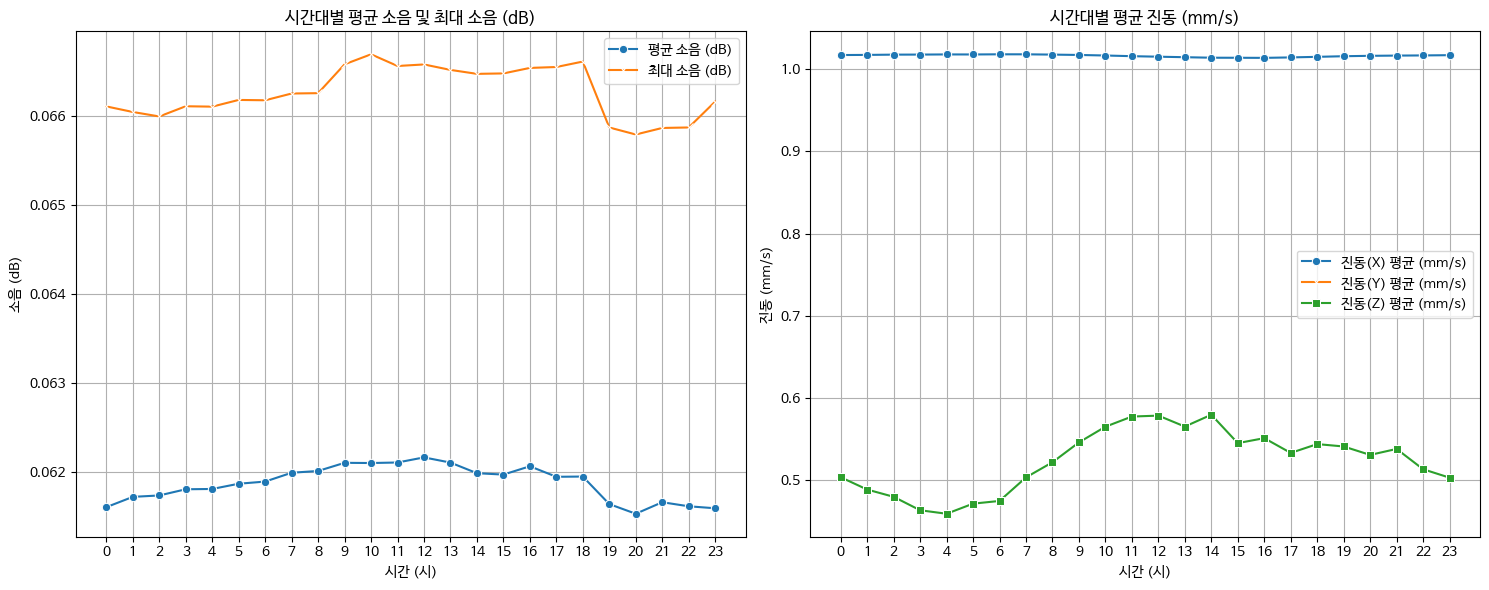

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# 시간대별 평균 소음 및 진동 계산
hourly_avg_data = sdot_hourly.groupby('hour_of_day')[['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']].mean().reset_index()

# 플롯 설정
plt.figure(figsize=(15, 6))

# 소음 데이터 플롯
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
sns.lineplot(x='hour_of_day', y='AVG_NIS', data=hourly_avg_data, label='평균 소음 (dB)', marker='o')
sns.lineplot(x='hour_of_day', y='MAX_NIS', data=hourly_avg_data, label='최대 소음 (dB)', marker='x')
plt.title('시간대별 평균 소음 및 최대 소음 (dB)')
plt.xlabel('시간 (시)')
plt.ylabel('소음 (dB)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

# 진동 데이터 플롯
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
sns.lineplot(x='hour_of_day', y='AVG_VIBR_XCRD', data=hourly_avg_data, label='진동(X) 평균 (mm/s)', marker='o')
sns.lineplot(x='hour_of_day', y='AVG_VIBR_YCRD', data=hourly_avg_data, label='진동(Y) 평균 (mm/s)', marker='x')
sns.lineplot(x='hour_of_day', y='AVG_VIBR_ZCRD', data=hourly_avg_data, label='진동(Z) 평균 (mm/s)', marker='s')
plt.title('시간대별 평균 진동 (mm/s)')
plt.xlabel('시간 (시)')
plt.ylabel('진동 (mm/s)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


### 시간대별 센서 소음 분포 (Ridgeplot)

각 센서의 시간대별 평균 소음(AVG_NIS) 분포를 릿지플롯으로 시각화합니다. 이를 통해 특정 시간대에 두드러지는 소음 패턴을 가진 센서를 파악할 수 있습니다.

데이터가 너무 많아 (총 66869행), 50000개 행으로 랜덤 샘플링합니다.
센서 시리얼 개수가 너무 많아 (총 406개), 상위 50개의 센서만 선택합니다.


<Figure size 1200x800 with 0 Axes>

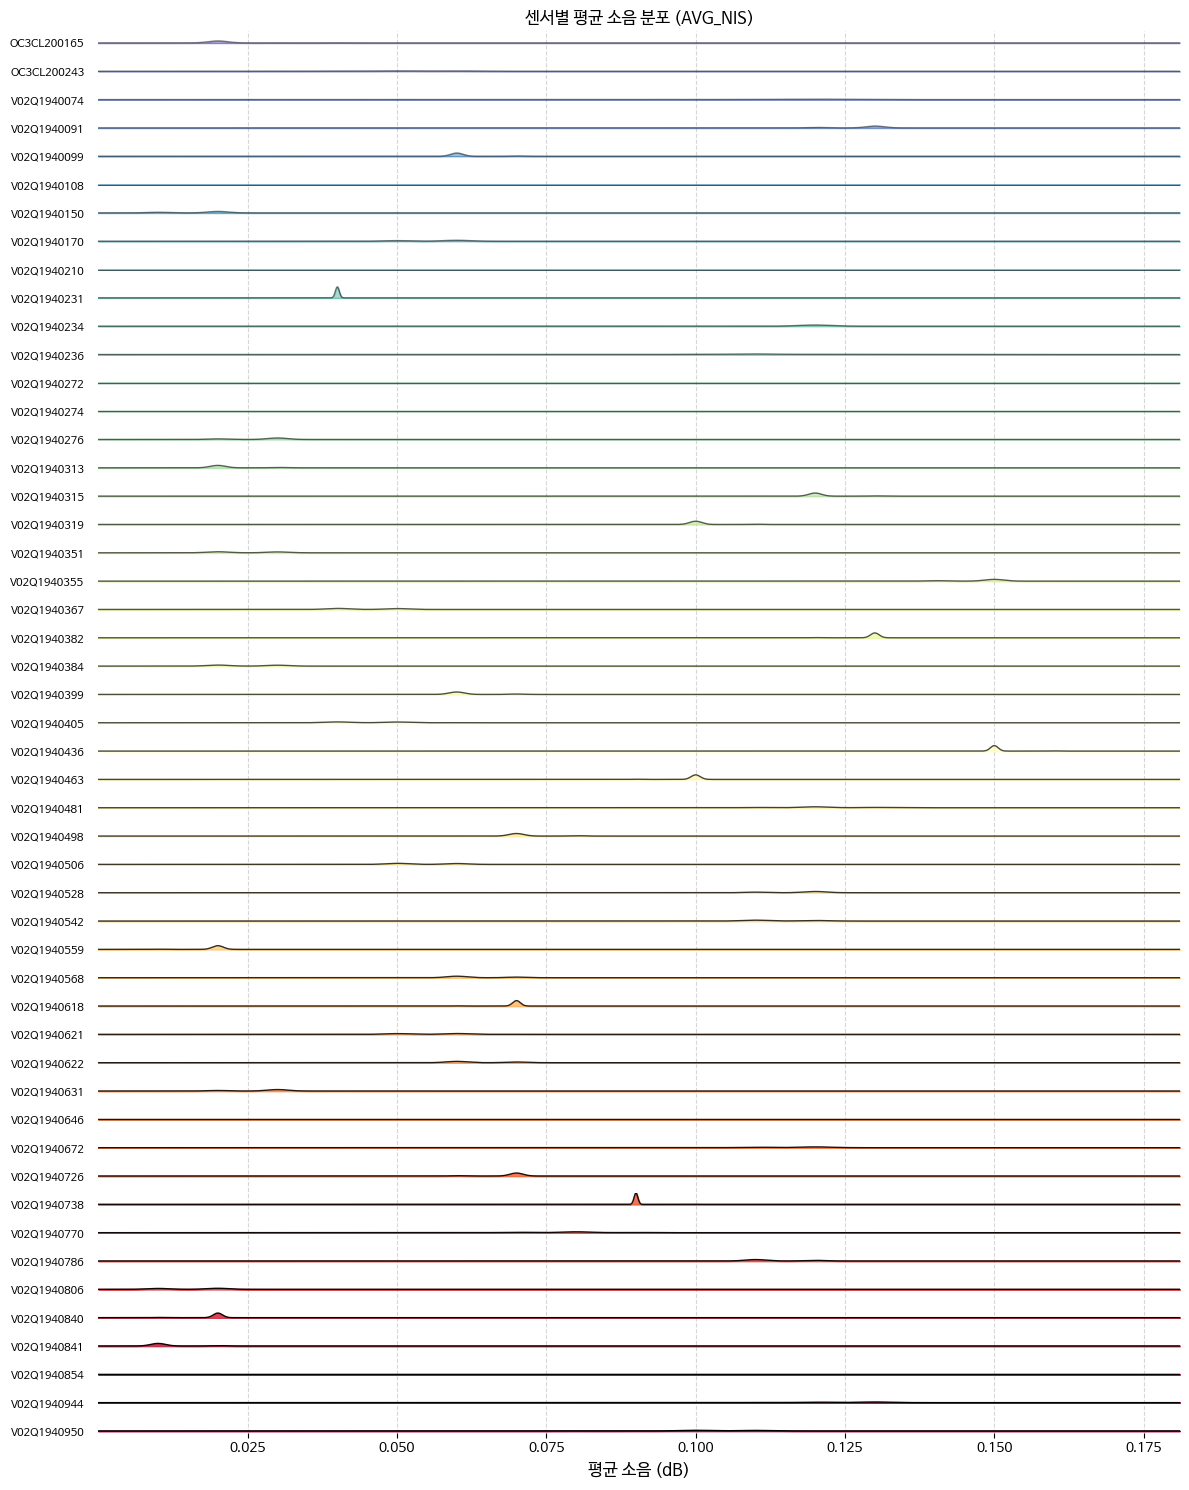

In [13]:
import joypy
import matplotlib.pyplot as plt

# 'MSRMT_HR' 컬럼은 이미 datetime 형식이며, 'hour_of_day'가 추출되어 있습니다.
# sdot_hourly_loaded DataFrame에서 필요한 컬럼들을 사용합니다.
# 데이터가 너무 많으면 plot이 복잡해질 수 있으므로, 일부 센서만 샘플링하거나
# 데이터프레임의 크기를 확인하는 것이 좋습니다.

# 필요한 데이터 준비 (sdot_hourly_loaded 사용)
# SERIAL_NO와 hour_of_day 별 AVG_NIS의 분포를 확인합니다.
# sdot_hourly_loaded는 이미 시간대별 평균이 집계된 상태이므로,
# 원래 데이터프레임 sdot_final을 사용하여 시간별 분포를 보는 것이 더 적합합니다.

# `sdot_final`이 존재하고, `MSRMT_HR`과 `SERIAL_NO`, `AVG_NIS`를 가지고 있다고 가정합니다.
# 만약 `sdot_final`이 너무 크다면 샘플링이 필요할 수 있습니다.
# sdot_final은 `czkeEbb3WJPF` 셀에서 생성됩니다.

if 'sdot_final' in locals() and not sdot_final.empty:
    plot_df = sdot_final[['SERIAL_NO', 'MSRMT_HR', 'AVG_NIS']].copy()
    plot_df['hour'] = plot_df['MSRMT_HR'].dt.hour

    # NaN 값 제거 (AVG_NIS에 NaN이 있으면 plot이 제대로 그려지지 않을 수 있음)
    plot_df = plot_df.dropna(subset=['AVG_NIS'])

    if not plot_df.empty:
        # --- 데이터 샘플링 로직 추가 ---
        # plot_df의 크기가 너무 클 경우, 랜덤 샘플링을 통해 속도 최적화
        max_plot_rows = 50000 # 플롯에 사용할 최대 데이터 행 수

        if len(plot_df) > max_plot_rows:
            print(f"데이터가 너무 많아 (총 {len(plot_df)}행), {max_plot_rows}개 행으로 랜덤 샘플링합니다.")
            plot_df = plot_df.sample(n=max_plot_rows, random_state=42) # 재현성을 위해 random_state 설정

        # 센서 개수가 너무 많으면 플롯이 복잡해지므로, 최대 50개의 센서만 선택
        unique_serials_count = plot_df['SERIAL_NO'].nunique()
        max_serials_to_plot = 50
        if unique_serials_count > max_serials_to_plot:
            print(f"센서 시리얼 개수가 너무 많아 (총 {unique_serials_count}개), 상위 {max_serials_to_plot}개의 센서만 선택합니다.")
            # 가장 많은 데이터를 가진 상위 N개 센서 선택
            top_serials = plot_df['SERIAL_NO'].value_counts().nlargest(max_serials_to_plot).index
            plot_df = plot_df[plot_df['SERIAL_NO'].isin(top_serials)]

        # --- 샘플링 로직 추가 끝 ---

        # AVG_NIS의 최소값과 최대값을 기반으로 x_range 설정
        min_avg_nis = plot_df['AVG_NIS'].min() - (plot_df['AVG_NIS'].std() * 0.5) # 여유 공간 확보
        max_avg_nis = plot_df['AVG_NIS'].max() + (plot_df['AVG_NIS'].std() * 0.5) # 여유 공간 확보
        if min_avg_nis < 0: min_avg_nis = 0 # 소음은 음수가 될 수 없음

        plt.figure(figsize=(12, 8))
        fig, axes = joypy.joyplot(plot_df, by='SERIAL_NO', column='AVG_NIS',
                                  hist=False, fade=True,
                                  x_range=[min_avg_nis, max_avg_nis], # AVG_NIS 값 범위에 맞게 조정
                                  overlap=1.2, linewidth=1, alpha=0.8, # overlap과 alpha 조정
                                  title='센서별 평균 소음 분포 (AVG_NIS)', # 제목 변경
                                  xlabelsize=10, ylabelsize=8,
                                  legend=False, figsize=(12, (len(plot_df['SERIAL_NO'].unique()) * 0.3)),
                                  colormap=plt.get_cmap('Spectral_r')) # Colormap을 객체로 변환

        plt.xlabel('평균 소음 (dB)', fontsize=12) # x축 라벨 변경
        plt.ylabel('센서 시리얼 번호', fontsize=12)
        # plt.xticks(range(0, 24)) # 더 이상 시간 범위가 아니므로 제거
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("릿지플롯을 그릴 데이터가 충분하지 않습니다 (AVG_NIS에 NaN 값이 많거나 데이터가 비어있음).")
else:
    print("sdot_final 데이터프레임을 찾을 수 없거나 비어 있습니다. 이전 셀들을 실행하여 sdot_final을 생성해주세요.")

### 시간대별 센서 소음 추이 (Line Plot)

각 센서의 시간대별 평균 소음(`AVG_NIS`)을 라인 플롯으로 시각화하여, 하루 동안의 소음 패턴 변화를 분석합니다. 소음 수준이 높은 상위 센서들을 중심으로 보여주어, 주요 소음 발생 센서들의 시간대별 특성을 파악할 수 있습니다.

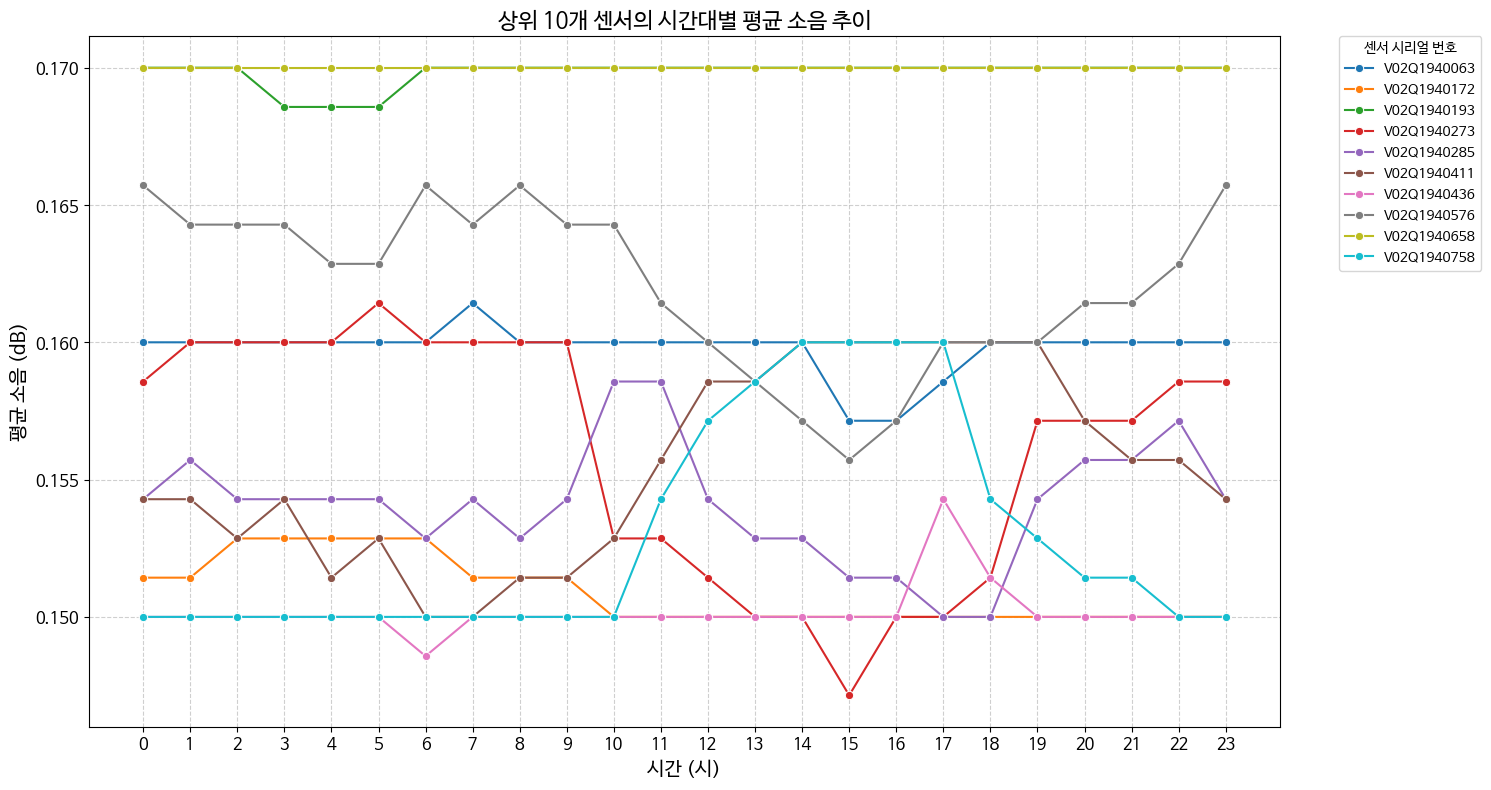

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# sdot_final 데이터프레임에서 필요한 컬럼만 선택하고, 'hour' 컬럼이 없으면 생성
if 'sdot_final' in locals() and not sdot_final.empty:
    noise_data = sdot_final[['SERIAL_NO', 'MSRMT_HR', 'AVG_NIS']].copy()
    noise_data['hour'] = noise_data['MSRMT_HR'].dt.hour

    # NaN 값 제거 (AVG_NIS에 NaN이 있으면 분석 및 플롯이 제대로 그려지지 않을 수 있음)
    noise_data = noise_data.dropna(subset=['AVG_NIS'])

    if not noise_data.empty:
        # 센서별 시간대별 평균 소음 계산
        hourly_avg_sensor_noise = noise_data.groupby(['SERIAL_NO', 'hour'])['AVG_NIS'].mean().reset_index()

        # 전체 기간 동안의 센서별 평균 소음 기준으로 상위 N개 센서 선택
        # 예를 들어, 상위 10개 센서를 선택합니다.
        top_n_sensors = hourly_avg_sensor_noise.groupby('SERIAL_NO')['AVG_NIS'].mean().nlargest(10).index.tolist()

        # 상위 N개 센서의 데이터만 필터링
        plot_data = hourly_avg_sensor_noise[hourly_avg_sensor_noise['SERIAL_NO'].isin(top_n_sensors)]

        plt.figure(figsize=(15, 8))
        sns.lineplot(data=plot_data, x='hour', y='AVG_NIS', hue='SERIAL_NO', marker='o')

        plt.title('상위 10개 센서의 시간대별 평균 소음 추이', fontsize=16)
        plt.xlabel('시간 (시)', fontsize=14)
        plt.ylabel('평균 소음 (dB)', fontsize=14)
        plt.xticks(range(0, 24), fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(title='센서 시리얼 번호', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print("라인 플롯을 그릴 데이터가 충분하지 않습니다 (AVG_NIS에 NaN 값이 많거나 데이터가 비어있음).")
else:
    print("sdot_final 데이터프레임을 찾을 수 없거나 비어 있습니다. 이전 셀들을 실행하여 sdot_final을 생성해주세요.")

### 24시간 도시의 맥박 (Circular Bar Plot) : "소음의 리듬"

24시간 시계 방향으로 소음 수치를 막대 그래프로 그려 도시의 소음 리듬을 시각화합니다. 특히 새벽 시간대 첫차와 밤 시간대 막차로 인한 소음 변화를 집중적으로 보여주어, '모두가 잠든 새벽, 첫차와 함께 도시의 평화가 깨지는 순간'이라는 메시지를 전달합니다.

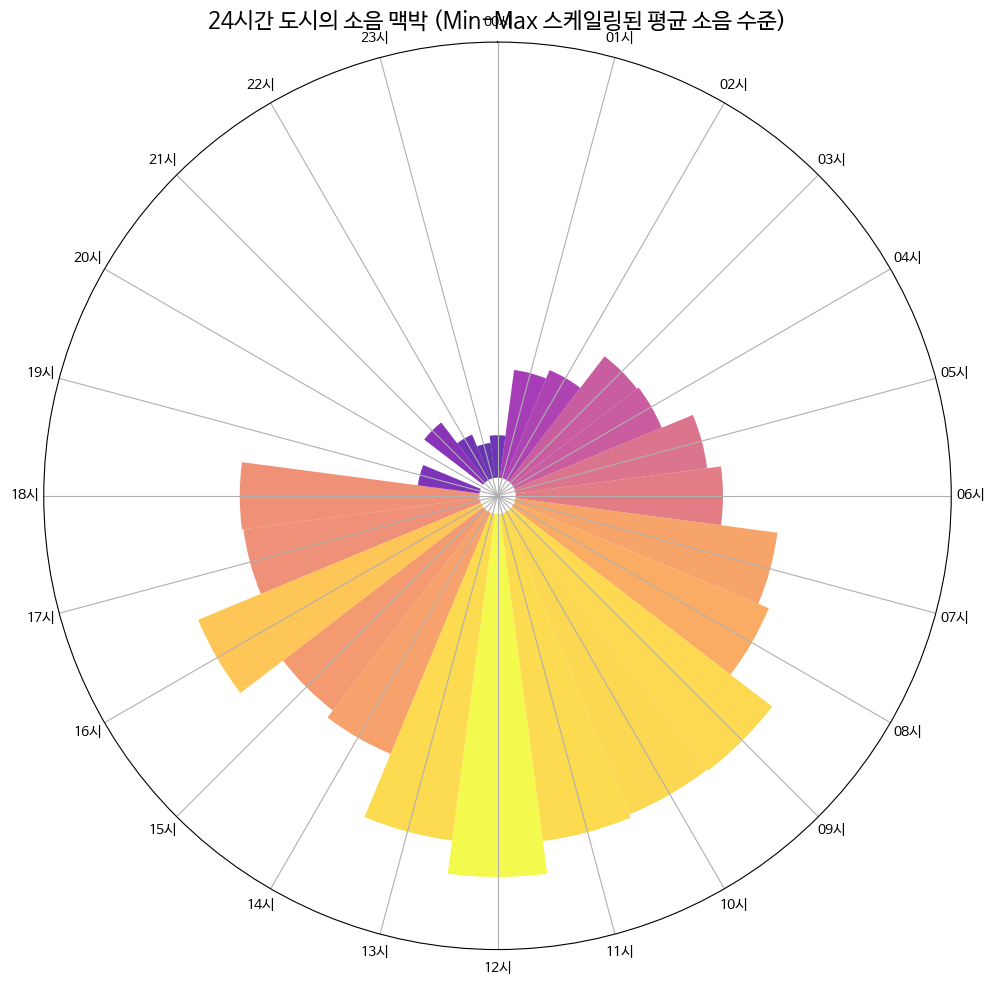

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 시간대별 평균 소음 데이터 준비
# sdot_hourly는 이미 SERIAL_NO와 hour_of_day로 집계된 데이터이므로, 이를 다시 hour_of_day로 평균 냅니다.
hourly_avg_noise_all_sensors = sdot_hourly.groupby('hour_of_day')['AVG_NIS'].mean().reset_index()

# 데이터 정렬 (0시부터 23시까지)
hourly_avg_noise_all_sensors = hourly_avg_noise_all_sensors.sort_values('hour_of_day').reset_index(drop=True)

# 극좌표 플롯 설정
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

# 각 시간대를 라디안 각도로 변환 (24시간 -> 2파이)
theta = np.linspace(0.0, 2 * np.pi, len(hourly_avg_noise_all_sensors), endpoint=False)
width = 2 * np.pi / len(hourly_avg_noise_all_sensors) # 각 바의 너비

# 소음 값을 높이로 사용
raw_heights = hourly_avg_noise_all_sensors['AVG_NIS'].values # .values를 사용하여 numpy 배열로 변환

# Min-Max 스케일링 적용
min_val = raw_heights.min()
max_val = raw_heights.max()

# 모든 값이 동일하여 min_val == max_val인 경우 0으로 나뉘는 것을 방지
if max_val == min_val:
    normalized_heights = np.zeros_like(raw_heights) # 모든 값을 0으로 설정
else:
    normalized_heights = (raw_heights - min_val) / (max_val - min_val)

# 시각적 가시성을 위해 바의 시작점(base_radius)과 스케일 조정 (scaled_heights)
base_radius = 0.1  # 바가 시작하는 기본 반지름 (조정 가능)
scale_factor = 2.0   # 정규화된 소음 값 스케일 조정 (조정 가능, 0~1 사이의 값을 적절히 증폭)
scaled_heights = normalized_heights * scale_factor

# 바 플롯 그리기
bars = ax.bar(theta, scaled_heights, width=width, bottom=base_radius,
              color=plt.cm.plasma(normalized_heights), alpha=0.8) # colormap을 plasma로 변경

# 0시를 위쪽(북쪽)에 배치하고 시계 방향으로 회전
ax.set_theta_zero_location('N') # 0시를 위쪽으로
ax.set_theta_direction(-1)      # 시계 방향으로 회전

# x축(시간) 라벨 설정
ax.set_xticks(theta)
ax.set_xticklabels([f'{h:02d}시' for h in hourly_avg_noise_all_sensors['hour_of_day']], fontsize=10)

# y축(소음) 라벨 숨기기 및 간격 조정
ax.set_yticks([]) # 소음 크기는 바의 높이로 직관적으로 파악
ax.set_ylim(0, base_radius + scaled_heights.max() * 1.2) # y축 범위 조정 (base_radius와 scaled_heights에 맞춰 조정)

# 제목 추가
plt.title('24시간 도시의 소음 맥박 (Min-Max 스케일링된 평균 소음 수준)', va='bottom', fontsize=16)
plt.tight_layout()
plt.show()

### 24시간 도시의 맥박: 진동(Z)의 리듬

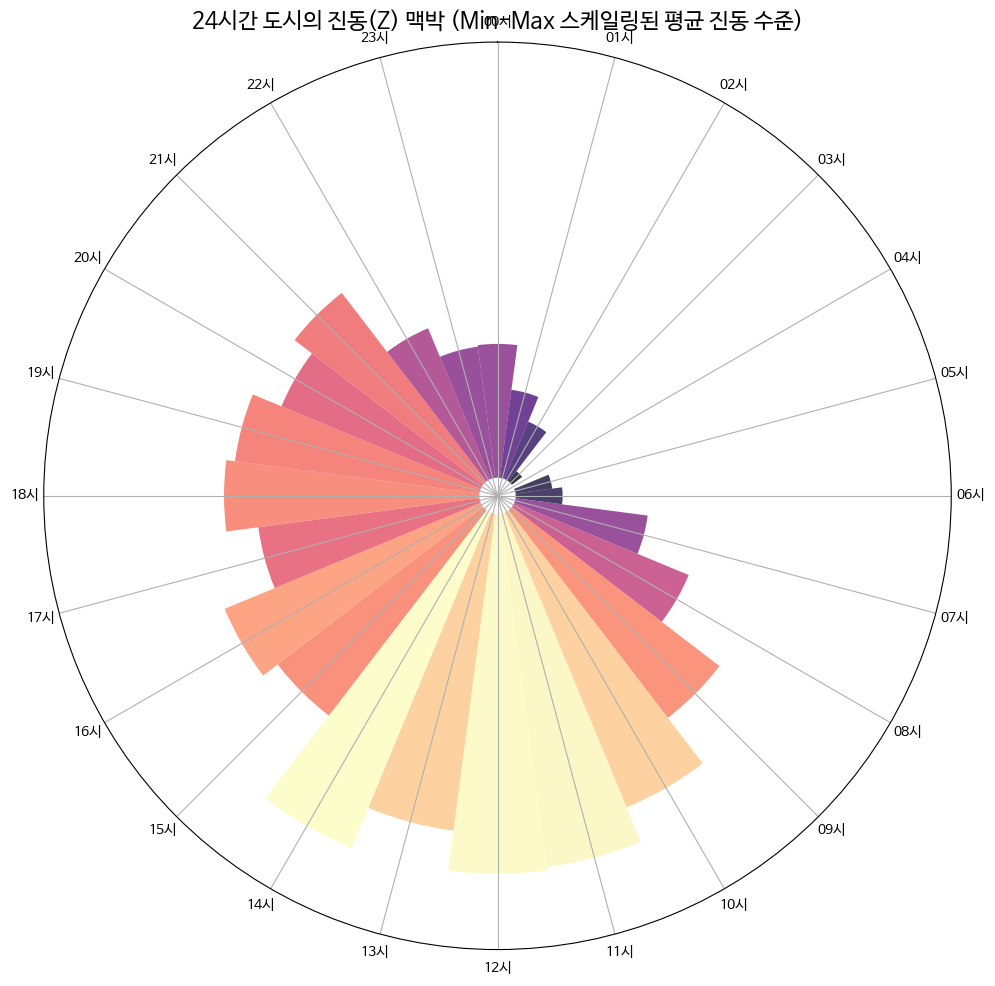

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 시간대별 평균 진동(Z) 데이터 준비
hourly_avg_vibration_z = sdot_hourly.groupby('hour_of_day')['AVG_VIBR_ZCRD'].mean().reset_index()

# NaN 값 제거 (데이터가 없는 시간대는 플롯에서 제외)
hourly_avg_vibration_z = hourly_avg_vibration_z.dropna(subset=['AVG_VIBR_ZCRD'])

if hourly_avg_vibration_z.empty:
    print("진동(Z) 데이터를 플롯할 수 없습니다. 시간대별 AVG_VIBR_ZCRD 값이 모두 NaN이거나 데이터가 없습니다.")
else:
    # 데이터 정렬 (0시부터 23시까지)
    hourly_avg_vibration_z = hourly_avg_vibration_z.sort_values('hour_of_day').reset_index(drop=True)

    # 극좌표 플롯 설정
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

    # 각 시간대를 라디안 각도로 변환 (24시간 -> 2파이)
    theta = np.linspace(0.0, 2 * np.pi, len(hourly_avg_vibration_z), endpoint=False)
    width = 2 * np.pi / len(hourly_avg_vibration_z) # 각 바의 너비

    # 진동 값을 높이로 사용
    raw_heights_z = hourly_avg_vibration_z['AVG_VIBR_ZCRD'].values

    # Min-Max 스케일링 적용
    min_val_z = raw_heights_z.min()
    max_val_z = raw_heights_z.max()

    if max_val_z == min_val_z:
        normalized_heights_z = np.zeros_like(raw_heights_z)
    else:
        normalized_heights_z = (raw_heights_z - min_val_z) / (max_val_z - min_val_z)

    # 시각적 가시성을 위해 바의 시작점(base_radius)과 스케일 조정 (scaled_heights)
    base_radius = 0.1
    scale_factor = 2.0
    scaled_heights_z = normalized_heights_z * scale_factor

    # 바 플롯 그리기
    bars = ax.bar(theta, scaled_heights_z, width=width, bottom=base_radius,
                  color=plt.cm.magma(normalized_heights_z), alpha=0.8) # colormap 변경

    # 0시를 위쪽(북쪽)에 배치하고 시계 방향으로 회전
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # x축(시간) 라벨 설정
    ax.set_xticks(theta)
    ax.set_xticklabels([f'{h:02d}시' for h in hourly_avg_vibration_z['hour_of_day']], fontsize=10)

    # y축 라벨 숨기기 및 간격 조정
    ax.set_yticks([])
    ax.set_ylim(0, base_radius + scaled_heights_z.max() * 1.2)

    # 제목 추가
    plt.title('24시간 도시의 진동(Z) 맥박 (Min-Max 스케일링된 평균 진동 수준)', va='bottom', fontsize=16)

    plt.tight_layout()
    plt.show()

### 24시간 도시의 맥박: 진동(X)의 리듬

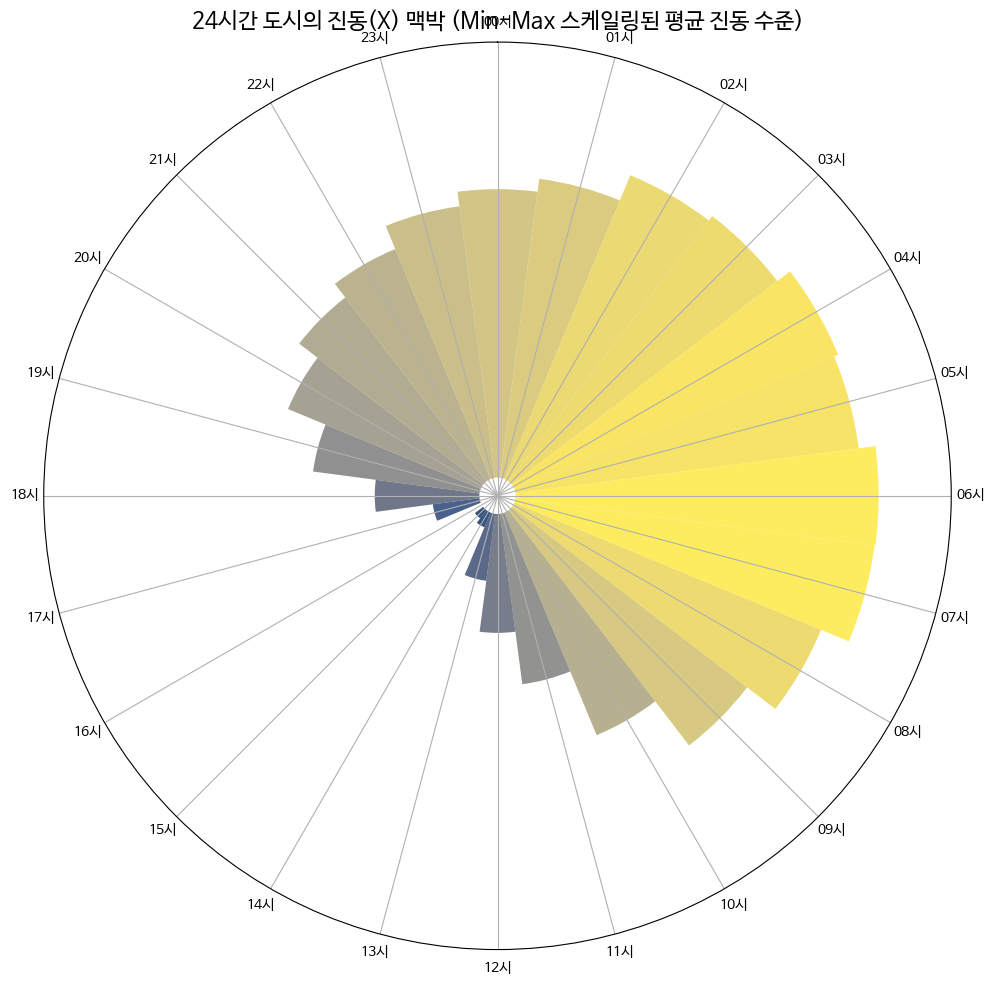

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 시간대별 평균 진동(X) 데이터 준비
hourly_avg_vibration_x = sdot_hourly.groupby('hour_of_day')['AVG_VIBR_XCRD'].mean().reset_index()

# NaN 값 제거 (데이터가 없는 시간대는 플롯에서 제외)
hourly_avg_vibration_x = hourly_avg_vibration_x.dropna(subset=['AVG_VIBR_XCRD'])

if hourly_avg_vibration_x.empty:
    print("진동(X) 데이터를 플롯할 수 없습니다. 시간대별 AVG_VIBR_XCRD 값이 모두 NaN이거나 데이터가 없습니다.")
else:
    # 데이터 정렬 (0시부터 23시까지)
    hourly_avg_vibration_x = hourly_avg_vibration_x.sort_values('hour_of_day').reset_index(drop=True)

    # 극좌표 플롯 설정
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

    # 각 시간대를 라디안 각도로 변환 (24시간 -> 2파이)
    theta = np.linspace(0.0, 2 * np.pi, len(hourly_avg_vibration_x), endpoint=False)
    width = 2 * np.pi / len(hourly_avg_vibration_x) # 각 바의 너비

    # 진동 값을 높이로 사용
    raw_heights_x = hourly_avg_vibration_x['AVG_VIBR_XCRD'].values

    # Min-Max 스케일링 적용
    min_val_x = raw_heights_x.min()
    max_val_x = raw_heights_x.max()

    if max_val_x == min_val_x:
        normalized_heights_x = np.zeros_like(raw_heights_x)
    else:
        normalized_heights_x = (raw_heights_x - min_val_x) / (max_val_x - min_val_x)

    # 시각적 가시성을 위해 바의 시작점(base_radius)과 스케일 조정 (scaled_heights)
    base_radius = 0.1
    scale_factor = 2.0
    scaled_heights_x = normalized_heights_x * scale_factor

    # 바 플롯 그리기
    bars = ax.bar(theta, scaled_heights_x, width=width, bottom=base_radius,
                  color=plt.cm.cividis(normalized_heights_x), alpha=0.8) # colormap 변경

    # 0시를 위쪽(북쪽)에 배치하고 시계 방향으로 회전
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # x축(시간) 라벨 설정
    ax.set_xticks(theta)
    ax.set_xticklabels([f'{h:02d}시' for h in hourly_avg_vibration_x['hour_of_day']], fontsize=10)

    # y축 라벨 숨기기 및 간격 조정
    ax.set_yticks([])
    ax.set_ylim(0, base_radius + scaled_heights_x.max() * 1.2)

    # 제목 추가
    plt.title('24시간 도시의 진동(X) 맥박 (Min-Max 스케일링된 평균 진동 수준)', va='bottom', fontsize=16)

    plt.tight_layout()
    plt.show()

### Plotly 차트 생성 및 HTML로 내보내기 (예시: 시간대별 평균 소음)

먼저 `plotly` 라이브러리를 설치하고, 기존 `matplotlib` 차트 중 하나를 `plotly`로 변환하여 HTML 파일로 저장하는 방법을 보여드리겠습니다. 다른 차트들도 유사한 방식으로 변환할 수 있습니다.

In [18]:
# plotly 라이브러리 설치 (처음 한 번만 실행)
!pip install plotly

In [19]:
import plotly.graph_objects as go
from plotly.offline import plot

# '시간대별 평균 소음 및 최대 소음' 데이터 (e7995b7b 셀에서 생성된 hourly_avg_data 사용)
# hourly_avg_data = sdot_hourly.groupby('hour_of_day')[['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']].mean().reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=hourly_avg_data['hour_of_day'],
    y=hourly_avg_data['AVG_NIS'],
    mode='lines+markers',
    name='평균 소음 (dB)'
))

fig.add_trace(go.Scatter(
    x=hourly_avg_data['hour_of_day'],
    y=hourly_avg_data['MAX_NIS'],
    mode='lines+markers',
    name='최대 소음 (dB)'
))

fig.update_layout(
    title='시간대별 평균 소음 및 최대 소음 (dB)',
    xaxis_title='시간 (시)',
    yaxis_title='소음 (dB)',
    xaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1)
)

# HTML 파일로 저장
plot(fig, filename='hourly_noise_plotly_chart.html', auto_open=False)

'hourly_noise_plotly_chart.html'

### Plotly 차트 생성 (시간대별 평균 진동 Z)

In [20]:
import plotly.graph_objects as go
from plotly.offline import plot

# '시간대별 평균 진동(Z)' 데이터 (1ec9961d 셀에서 생성된 hourly_avg_vibration_z 사용)
# Nan 값이 있는 경우 플롯에서 제외되도록 합니다.

vibration_z_fig = go.Figure()

vibration_z_fig.add_trace(go.Scatter(
    x=hourly_avg_vibration_z['hour_of_day'],
    y=hourly_avg_vibration_z['AVG_VIBR_ZCRD'],
    mode='lines+markers',
    name='평균 진동(Z) (mm/s)'
))

vibration_z_fig.update_layout(
    title='시간대별 평균 진동(Z) (mm/s)',
    xaxis_title='시간 (시)',
    yaxis_title='진동 (mm/s)',
    xaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1)
)

# HTML 파일로 저장 (개별 파일로 저장할 경우)
plot(vibration_z_fig, filename='hourly_vibration_z_plotly_chart.html', auto_open=False)

'hourly_vibration_z_plotly_chart.html'

### Plotly 차트 생성 (시간대별 평균 진동 X)

In [21]:
import plotly.graph_objects as go
from plotly.offline import plot

# '시간대별 평균 진동(X)' 데이터 (be788e94 셀에서 생성된 hourly_avg_vibration_x 사용)
# Nan 값이 있는 경우 플롯에서 제외되도록 합니다.

vibration_x_fig = go.Figure()

vibration_x_fig.add_trace(go.Scatter(
    x=hourly_avg_vibration_x['hour_of_day'],
    y=hourly_avg_vibration_x['AVG_VIBR_XCRD'],
    mode='lines+markers',
    name='평균 진동(X) (mm/s)'
))

vibration_x_fig.update_layout(
    title='시간대별 평균 진동(X) (mm/s)',
    xaxis_title='시간 (시)',
    yaxis_title='진동 (mm/s)',
    xaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1)
)

# HTML 파일로 저장 (개별 파일로 저장할 경우)
plot(vibration_x_fig, filename='hourly_vibration_x_plotly_chart.html', auto_open=False)

'hourly_vibration_x_plotly_chart.html'

### 세 가지 Plotly 차트를 하나의 HTML 대시보드로 통합

In [22]:
import os
import plotly.graph_objects as go
from plotly.offline import plot

# 1. Plotly 차트 Figure 객체 생성 (이전 셀들 참고)
# noise_fig는 이미 b49860fb 셀에서 생성되었습니다.
# vibration_z_fig는 방금 생성된 셀에서 생성되었습니다.
# vibration_x_fig는 방금 생성된 셀에서 생성되었습니다.

# 2. 각 차트의 div 문자열 얻기
# 첫 번째 차트에서만 Plotly JS 라이브러리를 포함하고, 나머지 차트들에서는 중복을 피합니다.
noise_chart_div = plot(fig, output_type='div', include_plotlyjs=True)
vibration_z_chart_div = plot(vibration_z_fig, output_type='div', include_plotlyjs=False)
vibration_x_chart_div = plot(vibration_x_fig, output_type='div', include_plotlyjs=False)

# 3. HTML 템플릿
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>S-DoT 환경 데이터 대시보드</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; }
        .chart-container { width: 48%; float: left; margin: 1%; border: 1px solid #ccc; padding: 10px; box-sizing: border-box; }
        .chart-full-width { width: 98%; margin: 1%; border: 1px solid #ccc; padding: 10px; box-sizing: border-box; clear: both; }
    </style>
</head>
<body>
    <h1>서울시 철도 주변 S-DoT 환경 데이터 대시보드</h1>

    <div class="chart-container">
        <h2>시간대별 평균 소음 및 최대 소음</h2>
        {noise_chart_div}
    </div>

    <div class="chart-container">
        <h2>시간대별 평균 진동(Z)</h2>
        {vibration_z_chart_div}
    </div>

    <div class="chart-full-width">
        <h2>시간대별 평균 진동(X)</h2>
        {vibration_x_chart_div}
    </div>

</body>
</html>
"""

# 4. 플레이스홀더를 실제 차트 div로 대체
final_html = html_template.replace('{noise_chart_div}', noise_chart_div)
final_html = final_html.replace('{vibration_z_chart_div}', vibration_z_chart_div)
final_html = final_html.replace('{vibration_x_chart_div}', vibration_x_chart_div)

# 5. 저장할 디렉토리 확인/생성 및 최종 HTML 파일 저장
save_dir = '/content/drive/MyDrive/SSAFY/BDC/html'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'sdot_dashboard.html')

with open(save_path, 'w', encoding='utf-8') as f:
    f.write(final_html)

print(f"대시보드 HTML 파일이 다음 경로에 생성되었습니다: {save_path}")

대시보드 HTML 파일이 다음 경로에 생성되었습니다: /content/drive/MyDrive/SSAFY/BDC/html/sdot_dashboard.html


### 대시보드 추가 시각화 1: 지도 기반 공간 시각화 (Plotly Mapbox)

역사 주변 센서의 평균 소음 수치를 바탕으로, 지도 위에 역사의 위치를 시각화합니다.

In [23]:
import plotly.express as px

# 결측치가 있는 경우를 대비해 유효한 데이터만 필터링
map_df = station_plot_df_filtered.dropna(subset=['AVG_NIS', '위도', '경도']).copy()

# Plotly Mapbox 산점도 그리기
fig_map = px.scatter_mapbox(map_df,
                            lat="위도",
                            lon="경도",
                            hover_name="역사명",
                            hover_data={"호선": True, "AVG_NIS": ":.3f", "AVG_VIBR_ZCRD": ":.3f", "NUM_NEARBY_SENSORS": True, "위도": False, "경도": False},
                            color="AVG_NIS",
                            size="AVG_NIS",  # 수치가 클수록 점 크기도 약간 커지게 설정
                            color_continuous_scale=px.colors.sequential.YlOrRd,  # 노란색 -> 빨간색 (소음이 높을수록 빨감)
                            zoom=10.5,
                            center={"lat": 37.5665, "lon": 126.9780}, # 서울 중심
                            title="서울시 철도 역사 주변 평균 소음(AVG_NIS) 공간 분포")

# mapbox_style 설정 ('carto-positron', 'open-street-map' 등 무료 타일 사용)
fig_map.update_layout(mapbox_style="carto-positron")
fig_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig_map.show()


### 대시보드 추가 시각화 2: 시간대별 주요 센서 소음 히트맵

전체 센서 중 평균 소음 수치가 가장 높은 상위 20개 센서를 추출하여, 24시간 동안의 소음 변화 패턴을 히트맵으로 시각화합니다.

In [24]:
import plotly.express as px

# 1. 평균 소음 기준 상위 20개 센서 추출
top_20_sensors = sdot_hourly.groupby('SERIAL_NO')['AVG_NIS'].mean().nlargest(20).index

# 2. 데이터 필터링 및 피벗 (시간대별 컬럼화)
heatmap_data = sdot_hourly[sdot_hourly['SERIAL_NO'].isin(top_20_sensors)]
heatmap_pivot = heatmap_data.pivot(index='SERIAL_NO', columns='hour_of_day', values='AVG_NIS')

# 센서들을 평균 소음 순으로 정렬하여 보기 좋게 만듦 (위쪽이 소음이 큼)
heatmap_pivot['mean_noise'] = heatmap_pivot.mean(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('mean_noise', ascending=True).drop(columns=['mean_noise'])

# 3. 히트맵 시각화
fig_heatmap = px.imshow(heatmap_pivot,
                        labels=dict(x="시간 (시)", y="센서 시리얼 번호", color="평균 소음 (dB)"),
                        x=heatmap_pivot.columns,
                        y=heatmap_pivot.index,
                        title="상위 20개 센서의 시간대별 평균 소음 히트맵",
                        color_continuous_scale='Reds',
                        aspect="auto")

# X축 레이블 간격 조정 (0시~23시 모두 표시)
fig_heatmap.update_xaxes(side="bottom", tickmode='linear', dtick=1)
fig_heatmap.show()


### 대시보드 업데이트: 5개의 차트를 하나의 HTML로 통합

이전에 생성한 3개의 차트(시간대별 소음, 진동 Z, 진동 X)와 새로 생성한 2개의 차트(공간 시각화 지도, 주요 센서 히트맵)를 모두 포함하는 종합 대시보드를 생성합니다.

In [25]:
import os
from plotly.offline import plot

# 1. 각 차트의 div 문자열 얻기
# 이미 생성된 fig (소음), vibration_z_fig, vibration_x_fig, fig_map, fig_heatmap 객체를 사용합니다.
# 첫 번째 차트에서만 Plotly JS 라이브러리를 포함합니다.
noise_chart_div = plot(fig, output_type='div', include_plotlyjs=True)
vibration_z_chart_div = plot(vibration_z_fig, output_type='div', include_plotlyjs=False)
vibration_x_chart_div = plot(vibration_x_fig, output_type='div', include_plotlyjs=False)
map_chart_div = plot(fig_map, output_type='div', include_plotlyjs=False)
heatmap_chart_div = plot(fig_heatmap, output_type='div', include_plotlyjs=False)

# 2. 통합 HTML 템플릿
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>S-DoT 환경 데이터 종합 대시보드</title>
    <style>
        body { font-family: 'Malgun Gothic', sans-serif; margin: 20px; background-color: #f4f7f6; }
        h1 { text-align: center; color: #333; }
        .dashboard-container { display: flex; flex-wrap: wrap; justify-content: space-between; }
        .chart-box { background-color: white; border-radius: 8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); margin-bottom: 20px; padding: 15px; box-sizing: border-box; }
        .half-width { width: 49%; }
        .full-width { width: 100%; }
        h2 { color: #555; border-bottom: 2px solid #eee; padding-bottom: 10px; }
    </style>
</head>
<body>
    <h1>서울시 철도 주변 S-DoT 환경 데이터 종합 대시보드</h1>

    <div class="dashboard-container">
        <!-- 첫 번째 줄: 지도와 히트맵 (전체적인 현황) -->
        <div class="chart-box half-width">
            <h2>📍 철도 역사 주변 평균 소음 공간 분포</h2>
            {map_chart_div}
        </div>
        <div class="chart-box half-width">
            <h2>🔥 상위 20개 센서 시간대별 소음 히트맵</h2>
            {heatmap_chart_div}
        </div>

        <!-- 두 번째 줄: 소음 및 진동 상세 추이 -->
        <div class="chart-box full-width">
            <h2>📈 시간대별 평균 및 최대 소음 추이</h2>
            {noise_chart_div}
        </div>

        <!-- 세 번째 줄: 24시간 진동 맥박 -->
        <div class="chart-box half-width">
            <h2>⏱️ 24시간 진동(Z) 맥박</h2>
            {vibration_z_chart_div}
        </div>
        <div class="chart-box half-width">
            <h2>⏱️ 24시간 진동(X) 맥박</h2>
            {vibration_x_chart_div}
        </div>
    </div>
</body>
</html>
"""

# 3. 플레이스홀더를 실제 차트 div로 대체
final_html = html_template.replace('{noise_chart_div}', noise_chart_div)
final_html = final_html.replace('{vibration_z_chart_div}', vibration_z_chart_div)
final_html = final_html.replace('{vibration_x_chart_div}', vibration_x_chart_div)
final_html = final_html.replace('{map_chart_div}', map_chart_div)
final_html = final_html.replace('{heatmap_chart_div}', heatmap_chart_div)

# 4. 파일 저장
save_dir = '/content/drive/MyDrive/SSAFY/BDC/html'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'sdot_comprehensive_dashboard.html')

with open(save_path, 'w', encoding='utf-8') as f:
    f.write(final_html)

print(f"✨ 총 5개의 차트가 포함된 종합 대시보드가 다음 경로에 생성되었습니다:\n{save_path}")


✨ 총 5개의 차트가 포함된 종합 대시보드가 다음 경로에 생성되었습니다:
/content/drive/MyDrive/SSAFY/BDC/html/sdot_comprehensive_dashboard.html


### 대시보드 최종 업데이트: 총 7개 차트 통합 (원형 차트 추가)

기존 5개의 차트에 24시간 도시의 맥박(소음, 진동Z) 원형 차트 2개를 추가하여 최종 HTML 대시보드를 생성합니다.

In [28]:
import plotly.graph_objects as go
from plotly.offline import plot
import os

# 필요한 데이터 재집계 (이전 셀 미실행 방지, sdot_hourly_loaded 사용)
hourly_avg_noise_all_sensors = sdot_hourly_loaded.groupby('hour_of_day')['AVG_NIS'].mean().reset_index()
hourly_avg_vibration_z = sdot_hourly_loaded.groupby('hour_of_day')['AVG_VIBR_ZCRD'].mean().reset_index().dropna(subset=['AVG_VIBR_ZCRD'])
hourly_avg_vibration_x = sdot_hourly_loaded.groupby('hour_of_day')['AVG_VIBR_XCRD'].mean().reset_index().dropna(subset=['AVG_VIBR_XCRD'])

# 1. Plotly 원형 막대 그래프(Polar Bar Chart) 생성
# 1-1. 소음의 리듬
fig_polar_noise = go.Figure(go.Barpolar(
    r=hourly_avg_noise_all_sensors['AVG_NIS'],
    theta=hourly_avg_noise_all_sensors['hour_of_day'] * 15, # 360도 / 24시간 = 15도
    width=[15]*24,
    marker_color=hourly_avg_noise_all_sensors['AVG_NIS'],
    marker_colorscale='Plasma',
    opacity=0.8,
    hovertemplate='시간: %{customdata}시<br>평균 소음: %{r:.2f} dB<extra></extra>',
    customdata=hourly_avg_noise_all_sensors['hour_of_day']
))
fig_polar_noise.update_layout(
    title='🔊 24시간 소음의 리듬 (Polar)',
    polar=dict(
        angularaxis=dict(tickvals=[i*15 for i in range(24)], ticktext=[f'{i}시' for i in range(24)], direction="clockwise", rotation=90),
        radialaxis=dict(visible=False)
    )
)

# 1-2. 진동(Z)의 리듬
fig_polar_z = go.Figure(go.Barpolar(
    r=hourly_avg_vibration_z['AVG_VIBR_ZCRD'],
    theta=hourly_avg_vibration_z['hour_of_day'] * 15,
    width=[15]*len(hourly_avg_vibration_z),
    marker_color=hourly_avg_vibration_z['AVG_VIBR_ZCRD'],
    marker_colorscale='Magma',
    opacity=0.8,
    hovertemplate='시간: %{customdata}시<br>평균 진동(Z): %{r:.4f} mm/s<extra></extra>',
    customdata=hourly_avg_vibration_z['hour_of_day']
))
fig_polar_z.update_layout(
    title='〰️ 24시간 진동(Z)의 리듬 (Polar)',
    polar=dict(
        angularaxis=dict(tickvals=[i*15 for i in range(24)], ticktext=[f'{i}시' for i in range(24)], direction="clockwise", rotation=90),
        radialaxis=dict(visible=False)
    )
)

# 2. 모든 차트를 HTML div로 변환 (총 7개)
noise_chart_div = plot(fig, output_type='div', include_plotlyjs=True) # 첫 차트에만 JS 포함
vibration_z_chart_div = plot(vibration_z_fig, output_type='div', include_plotlyjs=False)
vibration_x_chart_div = plot(vibration_x_fig, output_type='div', include_plotlyjs=False)
map_chart_div = plot(fig_map, output_type='div', include_plotlyjs=False)
heatmap_chart_div = plot(fig_heatmap, output_type='div', include_plotlyjs=False)
polar_noise_div = plot(fig_polar_noise, output_type='div', include_plotlyjs=False)
polar_z_div = plot(fig_polar_z, output_type='div', include_plotlyjs=False)

# 3. 새로운 종합 HTML 템플릿 구성
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>S-DoT 환경 데이터 종합 대시보드 (7 Charts)</title>
    <style>
        body { font-family: 'Malgun Gothic', sans-serif; margin: 20px; background-color: #f4f7f6; }
        h1 { text-align: center; color: #333; }
        .dashboard-container { display: flex; flex-wrap: wrap; justify-content: space-between; }
        .chart-box { background-color: white; border-radius: 8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); margin-bottom: 20px; padding: 15px; box-sizing: border-box; }
        .half-width { width: 49%; }
        .full-width { width: 100%; }
        h2 { color: #555; border-bottom: 2px solid #eee; padding-bottom: 10px; font-size: 18px; }
    </style>
</head>
<body>
    <h1>서울시 철도 주변 S-DoT 환경 데이터 최종 대시보드</h1>

    <div class="dashboard-container">
        <!-- 1. 지도 & 히트맵 -->
        <div class="chart-box half-width">
            <h2>📍 철도 역사 주변 평균 소음 공간 분포</h2>
            {map_chart_div}
        </div>
        <div class="chart-box half-width">
            <h2>🔥 상위 20개 센서 시간대별 소음 히트맵</h2>
            {heatmap_chart_div}
        </div>

        <!-- 2. 시간대별 라인 차트 -->
        <div class="chart-box full-width">
            <h2>📈 시간대별 평균 및 최대 소음 추이</h2>
            {noise_chart_div}
        </div>
        <div class="chart-box half-width">
            <h2>📈 시간대별 평균 진동(Z) 추이</h2>
            {vibration_z_chart_div}
        </div>
        <div class="chart-box half-width">
            <h2>📈 시간대별 평균 진동(X) 추이</h2>
            {vibration_x_chart_div}
        </div>

        <!-- 3. 원형 차트 (맥박) -->
        <div class="chart-box half-width">
            <h2>🔊 24시간 도시의 맥박: 소음의 리듬</h2>
            {polar_noise_div}
        </div>
        <div class="chart-box half-width">
            <h2>〰️ 24시간 도시의 맥박: 진동(Z)의 리듬</h2>
            {polar_z_div}
        </div>
    </div>
</body>
</html>
"""

# 4. 문자열 치환 및 파일 저장
final_html = html_template.replace('{noise_chart_div}', noise_chart_div)
final_html = final_html.replace('{vibration_z_chart_div}', vibration_z_chart_div)
final_html = final_html.replace('{vibration_x_chart_div}', vibration_x_chart_div)
final_html = final_html.replace('{map_chart_div}', map_chart_div)
final_html = final_html.replace('{heatmap_chart_div}', heatmap_chart_div)
final_html = final_html.replace('{polar_noise_div}', polar_noise_div)
final_html = final_html.replace('{polar_z_div}', polar_z_div)

save_dir = '/content/drive/MyDrive/SSAFY/BDC/html'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'sdot_final_dashboard_7_charts.html')

with open(save_path, 'w', encoding='utf-8') as f:
    f.write(final_html)

print(f"✨ 총 7개의 차트가 포함된 최종 대시보드가 완성되었습니다:\n{save_path}")


✨ 총 7개의 차트가 포함된 최종 대시보드가 완성되었습니다:
/content/drive/MyDrive/SSAFY/BDC/html/sdot_final_dashboard_7_charts.html


In [34]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import plot
import os
import numpy as np

# 1. 공간 분포 (산점도)
map_df = station_plot_df_filtered.dropna(subset=['AVG_NIS', '위도', '경도']).copy()
fig_scatter = px.scatter(map_df, x="경도", y="위도", hover_name="역사명",
                         size="AVG_NIS", color="AVG_NIS",
                         color_continuous_scale="YlOrRd",
                         title="")
fig_scatter.update_layout(xaxis_title="경도", yaxis_title="위도", template="plotly_white", margin=dict(t=30, l=10, r=10, b=10))

# 2. 상위 20개 센서 시간대별 소음 히트맵
top_20_sensors = sdot_hourly_loaded.groupby('SERIAL_NO')['AVG_NIS'].mean().nlargest(20).index
heatmap_data = sdot_hourly_loaded[sdot_hourly_loaded['SERIAL_NO'].isin(top_20_sensors)]
heatmap_pivot = heatmap_data.pivot(index='SERIAL_NO', columns='hour_of_day', values='AVG_NIS')
heatmap_pivot['mean_noise'] = heatmap_pivot.mean(axis=1)
heatmap_pivot = heatmap_pivot.sort_values('mean_noise', ascending=True).drop(columns=['mean_noise'])
fig_heatmap = px.imshow(heatmap_pivot, labels=dict(x="시간 (시)", y="센서 시리얼", color="평균 소음 (dB)"),
                        x=heatmap_pivot.columns, y=heatmap_pivot.index,
                        title="", color_continuous_scale="Reds", aspect="auto")
fig_heatmap.update_xaxes(side="bottom", tickmode='linear', dtick=1)
fig_heatmap.update_layout(margin=dict(t=30, l=10, r=10, b=10))

# 3. 맥박 차트 (사용자 제공 Matplotlib 로직을 Plotly Barpolar로 완벽 적용!)
base_radius = 0.1
scale_factor = 2.0

# -- 소음 맥박 --
raw_noise = hourly_avg_noise_all_sensors['AVG_NIS'].values
min_noise, max_noise = raw_noise.min(), raw_noise.max()
norm_noise = np.zeros_like(raw_noise) if max_noise == min_noise else (raw_noise - min_noise) / (max_noise - min_noise)
scaled_noise = norm_noise * scale_factor

fig_polar_noise = go.Figure(go.Barpolar(
    r=scaled_noise,
    theta=hourly_avg_noise_all_sensors['hour_of_day'] * 15,
    width=[15]*24,
    marker_color=norm_noise,
    marker_colorscale='Plasma',
    base=base_radius,
    opacity=0.8,
    customdata=np.stack((hourly_avg_noise_all_sensors['hour_of_day'], raw_noise), axis=-1),
    hovertemplate='시간: %{customdata[0]}시<br>평균 소음: %{customdata[1]:.4f} dB<extra></extra>'
))
fig_polar_noise.update_layout(
    title='',
    polar=dict(
        angularaxis=dict(tickvals=[i*15 for i in range(24)], ticktext=[f'{i}시' for i in range(24)], direction="clockwise", rotation=90),
        radialaxis=dict(visible=False, range=[0, base_radius + scaled_noise.max() * 1.2])
    ),
    margin=dict(t=30, l=10, r=10, b=10)
)

# -- 진동(Z) 맥박 --
raw_z = hourly_avg_vibration_z['AVG_VIBR_ZCRD'].values
min_z, max_z = raw_z.min(), raw_z.max()
norm_z = np.zeros_like(raw_z) if max_z == min_z else (raw_z - min_z) / (max_z - min_z)
scaled_z = norm_z * scale_factor

fig_polar_z = go.Figure(go.Barpolar(
    r=scaled_z,
    theta=hourly_avg_vibration_z['hour_of_day'] * 15,
    width=[15]*len(raw_z),
    marker_color=norm_z,
    marker_colorscale='Magma',
    base=base_radius,
    opacity=0.8,
    customdata=np.stack((hourly_avg_vibration_z['hour_of_day'], raw_z), axis=-1),
    hovertemplate='시간: %{customdata[0]}시<br>평균 진동(Z): %{customdata[1]:.4f} mm/s<extra></extra>'
))
fig_polar_z.update_layout(
    title='',
    polar=dict(
        angularaxis=dict(tickvals=[i*15 for i in range(24)], ticktext=[f'{i}시' for i in range(24)], direction="clockwise", rotation=90),
        radialaxis=dict(visible=False, range=[0, base_radius + scaled_z.max() * 1.2])
    ),
    margin=dict(t=30, l=10, r=10, b=10)
)

# -- 시간대별 라인 차트 타이틀 제거 (HTML 헤더로 대체) --
fig.update_layout(title="", margin=dict(t=30, l=10, r=10, b=10))
vibration_z_fig.update_layout(title="", margin=dict(t=30, l=10, r=10, b=10))
vibration_x_fig.update_layout(title="", margin=dict(t=30, l=10, r=10, b=10))

# --- HTML 생성 및 저장 ---
# Plotly.js 전역 로드 (include_plotlyjs=False) 및 반응형 설정(responsive=True) 적용
plot_config = {'responsive': True}
scatter_div = plot(fig_scatter, output_type='div', include_plotlyjs=False, config=plot_config)
heatmap_div = plot(fig_heatmap, output_type='div', include_plotlyjs=False, config=plot_config)
polar_noise_div = plot(fig_polar_noise, output_type='div', include_plotlyjs=False, config=plot_config)
polar_z_div = plot(fig_polar_z, output_type='div', include_plotlyjs=False, config=plot_config)
noise_line_div = plot(fig, output_type='div', include_plotlyjs=False, config=plot_config)
vibr_z_line_div = plot(vibration_z_fig, output_type='div', include_plotlyjs=False, config=plot_config)
vibr_x_line_div = plot(vibration_x_fig, output_type='div', include_plotlyjs=False, config=plot_config)

html_template = """
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>S-DoT 환경 데이터 대시보드</title>
    <link rel="stylesheet" as="style" crossorigin href="https://cdn.jsdelivr.net/gh/orioncactus/pretendard@v1.3.8/dist/web/variable/pretendardvariable.css" />
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        body {
            font-family: 'Pretendard Variable', Pretendard, -apple-system, BlinkMacSystemFont, system-ui, Roboto, "Helvetica Neue", "Segoe UI", "Apple SD Gothic Neo", "Noto Sans KR", "Malgun Gothic", sans-serif;
            margin: 0;
            padding: 40px 20px;
            background-color: #f8f9fa;
            color: #212529;
        }
        .header-container {
            text-align: center;
            margin-bottom: 50px;
        }
        h1 {
            font-size: 2.5rem;
            font-weight: 800;
            color: #212529;
            margin-bottom: 10px;
            letter-spacing: -0.02em;
        }
        .subtitle {
            font-size: 1.1rem;
            color: #6c757d;
            font-weight: 400;
            margin-top: 0;
        }
        .dashboard-container {
            max-width: 1400px;
            margin: 0 auto;
            display: flex;
            flex-wrap: wrap;
            gap: 24px;
            justify-content: center;
        }
        .chart-box {
            background-color: #ffffff;
            border-radius: 20px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.04);
            padding: 24px;
            box-sizing: border-box;
            transition: transform 0.3s ease, box-shadow 0.3s ease;
            display: flex;
            flex-direction: column;
            min-height: 480px; /* 추가: 컨테이너 최소 높이 */
        }
        .chart-box:hover {
            transform: translateY(-5px);
            box-shadow: 0 15px 40px rgba(0,0,0,0.08);
        }
        .half-width {
            width: calc(50% - 12px);
        }
        .full-width {
            width: 100%;
        }
        h2 {
            font-size: 1.2rem;
            color: #343a40;
            margin-top: 0;
            margin-bottom: 16px;
            font-weight: 700;
            display: flex;
            align-items: center;
            gap: 8px;
        }
        .chart-content {
            flex-grow: 1;
            position: relative;
            min-height: 400px; /* 추가: 차트 영역 최소 높이 */
            width: 100%;
        }
        @media (max-width: 1024px) {
            .half-width { width: 100%; }
            padding: 20px 15px;
        }
    </style>
</head>
<body>
    <div class="header-container">
        <h1>서울시 철도 주변 S-DoT 환경 데이터 대시보드</h1>
        <p class="subtitle">24시간 도시의 맥박과 환경 데이터를 시각적으로 분석합니다.</p>
    </div>

    <div class="dashboard-container">
        <!-- 1. 원형 차트 (맥박) -->
        <div class="chart-box half-width">
            <h2>🔊 24시간 도시의 소음 맥박</h2>
            <div class="chart-content">{polar_noise_div}</div>
        </div>
        <div class="chart-box half-width">
            <h2>〰️ 24시간 진동(Z)의 맥박</h2>
            <div class="chart-content">{polar_z_div}</div>
        </div>

        <!-- 2. 공간 분포 산점도 & 히트맵 -->
        <div class="chart-box half-width">
            <h2>📍 철도 역사 주변 평균 소음 공간 분포</h2>
            <div class="chart-content">{scatter_div}</div>
        </div>
        <div class="chart-box half-width">
            <h2>🔥 상위 20개 센서 시간대별 소음 히트맵</h2>
            <div class="chart-content">{heatmap_div}</div>
        </div>

        <!-- 3. 시간대별 라인 차트 -->
        <div class="chart-box full-width">
            <h2>📈 시간대별 평균 및 최대 소음 추이</h2>
            <div class="chart-content">{noise_line_div}</div>
        </div>
        <div class="chart-box half-width">
            <h2>📈 시간대별 평균 진동(Z) 추이</h2>
            <div class="chart-content">{vibr_z_line_div}</div>
        </div>
        <div class="chart-box half-width">
            <h2>📈 시간대별 평균 진동(X) 추이</h2>
            <div class="chart-content">{vibr_x_line_div}</div>
        </div>
    </div>
</body>
</html>
"""

final_html = html_template.replace('{scatter_div}', scatter_div)
final_html = final_html.replace('{heatmap_div}', heatmap_div)
final_html = final_html.replace('{polar_noise_div}', polar_noise_div)
final_html = final_html.replace('{polar_z_div}', polar_z_div)
final_html = final_html.replace('{noise_line_div}', noise_line_div)
final_html = final_html.replace('{vibr_z_line_div}', vibr_z_line_div)
final_html = final_html.replace('{vibr_x_line_div}', vibr_x_line_div)

save_dir = '/content/drive/MyDrive/SSAFY/BDC/html'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'sdot_final_dashboard_aesthetic.html')

with open(save_path, 'w', encoding='utf-8') as f:
    f.write(final_html)

print(f"✨ 감각적인 UI/UX가 적용된 최종 대시보드가 완성되었습니다:\n{save_path}")


✨ 감각적인 UI/UX가 적용된 최종 대시보드가 완성되었습니다:
/content/drive/MyDrive/SSAFY/BDC/html/sdot_final_dashboard_aesthetic.html
